In [ ]:
# PART A
# installing packages

!pip install yfinance
!pip install yahoofinancials

import yfinance as yf
from yahoofinancials import YahooFinancials
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import numpy as np
import plotly.graph_objects as go

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=31fc3fb9c879288c31e11b573952ec96135c3bb0f3ea85d0fa0fb880710d929a
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


In [ ]:
# extracting the s&p 500 tickers from wikipedia

import requests
from io import StringIO

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
tables = pd.read_html(StringIO(response.text))

df_sp500 = tables[0]
tickers = df_sp500['Symbol'].tolist()
companies_dict = dict(zip(df_sp500['Symbol'], df_sp500['Security']))

print(f"Total tickers extracted: {len(tickers)}")
print(f"Sample tickers: {tickers[:10]}")
print(df_sp500[['Symbol', 'Security', 'GICS Sector']].head(10))

Total tickers extracted: 503
Sample tickers: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']
  Symbol                Security             GICS Sector
0    MMM                      3M             Industrials
1    AOS             A. O. Smith             Industrials
2    ABT     Abbott Laboratories             Health Care
3   ABBV                  AbbVie             Health Care
4    ACN               Accenture  Information Technology
5   ADBE              Adobe Inc.  Information Technology
6    AMD  Advanced Micro Devices  Information Technology
7    AES         AES Corporation               Utilities
8    AFL                   Aflac              Financials
9      A    Agilent Technologies             Health Care


In [ ]:
# defining start and end date

start_date = '2022-01-01'
end_date = '2025-01-01'

# download all the tickers

raw_data = yf.download(tickers, start = start_date, end = end_date, auto_adjust=True)

stock_open = np.array(raw_data['Open']).T
stock_close = np.array(raw_data['Close']).T

[**********************87%*****************      ]  440 of 503 completedERROR:yfinance:Failed to get ticker 'PFG' reason: Failed to perform, curl: (28) Operation timed out after 10001 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01)')
ERROR:yfinance:['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


In [ ]:
# cleaning the data / missing tickers

close_prices = raw_data['Close']

# dropping failed downloads
close_prices_clean = close_prices.dropna(axis=1, how='all')

# dropping any remaining NaN values
close_prices_clean = close_prices_clean.dropna(axis=1)

# checking

print(f"Original shpae: {close_prices.shape}")
print(f"Cleaned shape: {close_prices_clean.shape}")

# updating np array after cleaning

stock_close_clean = np.array(close_prices_clean).T

Original shpae: (753, 503)
Cleaned shape: (753, 493)


In [ ]:
# Calculations - Daily returns

# Formula is (Price Today - Price Yesterday) / Price Yesterday

daily_returns = close_prices_clean.pct_change()

#dropping first row since there's no previous day

daily_returns = daily_returns.dropna()

print(f"Daily returns shape: {daily_returns.shape}")
print(f"Sample daily returns:")
print(daily_returns.head())

Daily returns shape: (752, 493)
Sample daily returns:
Ticker             A      AAPL      ABBV      ABNB       ABT      ACGL  \
Date                                                                     
2022-01-04 -0.033806 -0.012691 -0.001920 -0.010887 -0.023518  0.013019   
2022-01-05 -0.017131 -0.026600  0.005253 -0.050059 -0.004493 -0.011744   
2022-01-06  0.003499 -0.016693 -0.004710 -0.015408 -0.000148  0.005830   
2022-01-07 -0.026623  0.000988 -0.002588  0.039437  0.003108  0.004681   
2022-01-10  0.000069  0.000116  0.011195 -0.032159 -0.002213  0.021078   

Ticker           ACN      ADBE       ADI       ADM  ...        WY      WYNN  \
Date                                                ...                       
2022-01-04 -0.007146 -0.018374 -0.009032  0.018560  ...  0.012817 -0.003190   
2022-01-05 -0.017611 -0.071426 -0.015438 -0.007809  ... -0.024823 -0.037033   
2022-01-06 -0.048290 -0.000603  0.003182  0.008891  ...  0.007986  0.004629   
2022-01-07 -0.019180 -0.006652 -

In [ ]:
# Beta - correlation (stock returns, index returns) x (σ_stock / σ_index)

# downloading index data

sp500_index = yf.download('^GSPC', start = start_date, end = end_date, auto_adjust=True)
index_returns = sp500_index['Close'].pct_change().dropna()

# aligning index with the stock returns to be on the same dates

index_returns = index_returns.squeeze()
index_returns = index_returns.reindex(daily_returns.index)

# calculating beta

beta = {}
for ticker in daily_returns.columns:
  stock_returns = daily_returns[ticker]
  correlation = stock_returns.corr(index_returns)
  beta[ticker] = correlation * (daily_returns[ticker].std() / index_returns.std())

beta_series = pd.Series(beta)

print(f"Beta calculated for {len(beta_series)} tickers")
print(f"\nSample beta values:")
print(beta_series.head(10))
print(f"\nbeta stats:")
print(beta_series.describe())

[*********************100%***********************]  1 of 1 completed

Beta calculated for 493 tickers

Sample beta values:
A       1.024800
AAPL    1.210689
ABBV    0.299097
ABNB    1.666256
ABT     0.672317
ACGL    0.569789
ACN     1.094208
ADBE    1.447974
ADI     1.339929
ADM     0.551200
dtype: float64

beta stats:
count    493.000000
mean       0.944770
std        0.432714
min        0.133249
25%        0.633410
50%        0.912897
75%        1.156199
max        3.294068
dtype: float64


# about the beta values and stats

493 tickers — beta calculated for all clean stocks

Mean beta = 0.94 — slightly below 1, meaning the average stock moves marginally less than the index

Min = 0.13 (very low risk, e.g. ABBV at 0.30) — defensive stocks that barely move with the market

Max = 3.29 — highly volatile stock, moves 3x the market

50% of stocks have beta < 0.91 — majority are slightly less volatile than the index

In [ ]:
# annual volatility - daily returns st dev x rad 252

annual_volatility = daily_returns.std() * np.sqrt(252)

print(f"Annual volatility calculated for {len(annual_volatility)} tickers")
print(f"\nSample annual volatility values:")
print(annual_volatility.head(10))
print(f"\nAnnual volatility stats:")
print(annual_volatility.describe())

Annual volatility calculated for 493 tickers

Sample annual volatility values:
Ticker
A       0.296259
AAPL    0.270935
ABBV    0.219958
ABNB    0.467875
ABT     0.217839
ACGL    0.253997
ACN     0.270331
ADBE    0.383083
ADI     0.318058
ADM     0.294044
dtype: float64

Annual volatility stats:
count    493.000000
mean       0.314467
std        0.114817
min        0.156193
25%        0.240149
50%        0.285111
75%        0.357287
max        1.341039
dtype: float64


about the beta values and stats

493 tickers — volatility calculated for all clean stocks

Mean volatility = 31.3% — average stock moves about 31% annually

Min = 15.6% — very stable stock (likely utilities or consumer staples)

Max = 134% — extremely volatile stock

50% of stocks below 28.5% — majority are moderately volatile


In [ ]:
# combining all 3 metrics into one df

metrics_df = pd.DataFrame({
    'Beta': beta_series,
    'Annual Volatility': annual_volatility,
    'Daily_Return' : daily_returns.mean()
    })

# adding sector info from the wiki table

metrics_df['Sector'] = df_sp500.set_index('Symbol')['GICS Sector']

print(metrics_df.shape)
print(metrics_df.head(10))
print(f"\nMissing values:\n{metrics_df.isna().sum()}")

(493, 4)
          Beta  Annual Volatility  Daily_Return                  Sector
A     1.024800           0.296259     -0.000002             Health Care
AAPL  1.210689           0.270935      0.000591  Information Technology
ABBV  0.299097           0.219958      0.000610             Health Care
ABNB  1.666256           0.467875      0.000074  Consumer Discretionary
ABT   0.672317           0.217839     -0.000106             Health Care
ACGL  0.569789           0.253997      0.001165              Financials
ACN   1.094208           0.270331      0.000011  Information Technology
ADBE  1.447974           0.383083     -0.000022  Information Technology
ADI   1.339929           0.318058      0.000514  Information Technology
ADM   0.551200           0.294044     -0.000111        Consumer Staples

Missing values:
Beta                 0
Annual Volatility    0
Daily_Return         0
Sector               0
dtype: int64


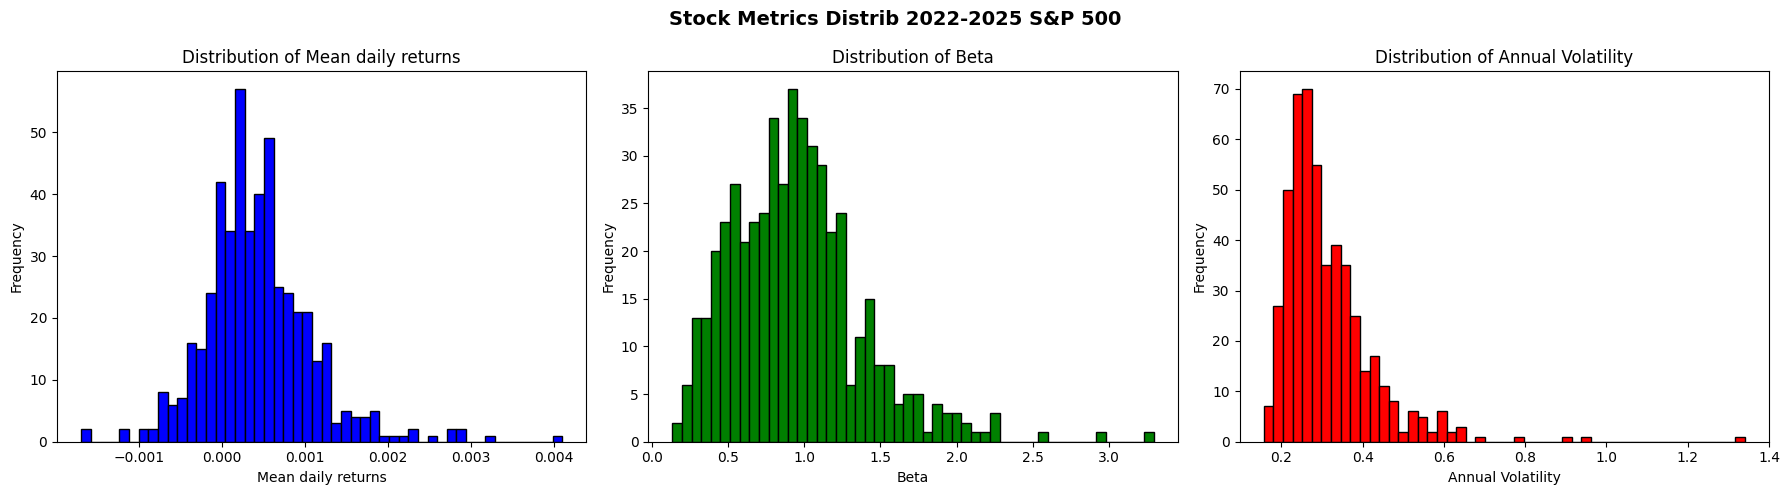

In [ ]:
 # visualisation of the metrics for stock segmentation

fig, axes = plt.subplots(1,3, figsize =(18, 5))

# daily return distribution

axes[0].hist(metrics_df['Daily_Return'], bins = 50, color = 'blue', edgecolor = 'black')
axes[0].set_title('Distribution of Mean daily returns')
axes[0].set_xlabel('Mean daily returns')
axes[0].set_ylabel('Frequency')

# beta distribution

axes[1].hist(metrics_df['Beta'], bins = 50, color = 'green', edgecolor = 'black')
axes[1].set_title('Distribution of Beta')
axes[1].set_xlabel('Beta')
axes[1].set_ylabel('Frequency')

# annual volatility distribution

axes[2].hist(metrics_df['Annual Volatility'], bins = 50, color = 'red', edgecolor = 'black')
axes[2].set_title('Distribution of Annual Volatility')
axes[2].set_xlabel('Annual Volatility')
axes[2].set_ylabel('Frequency')

plt.suptitle('Stock Metrics Distrib 2022-2025 S&P 500', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

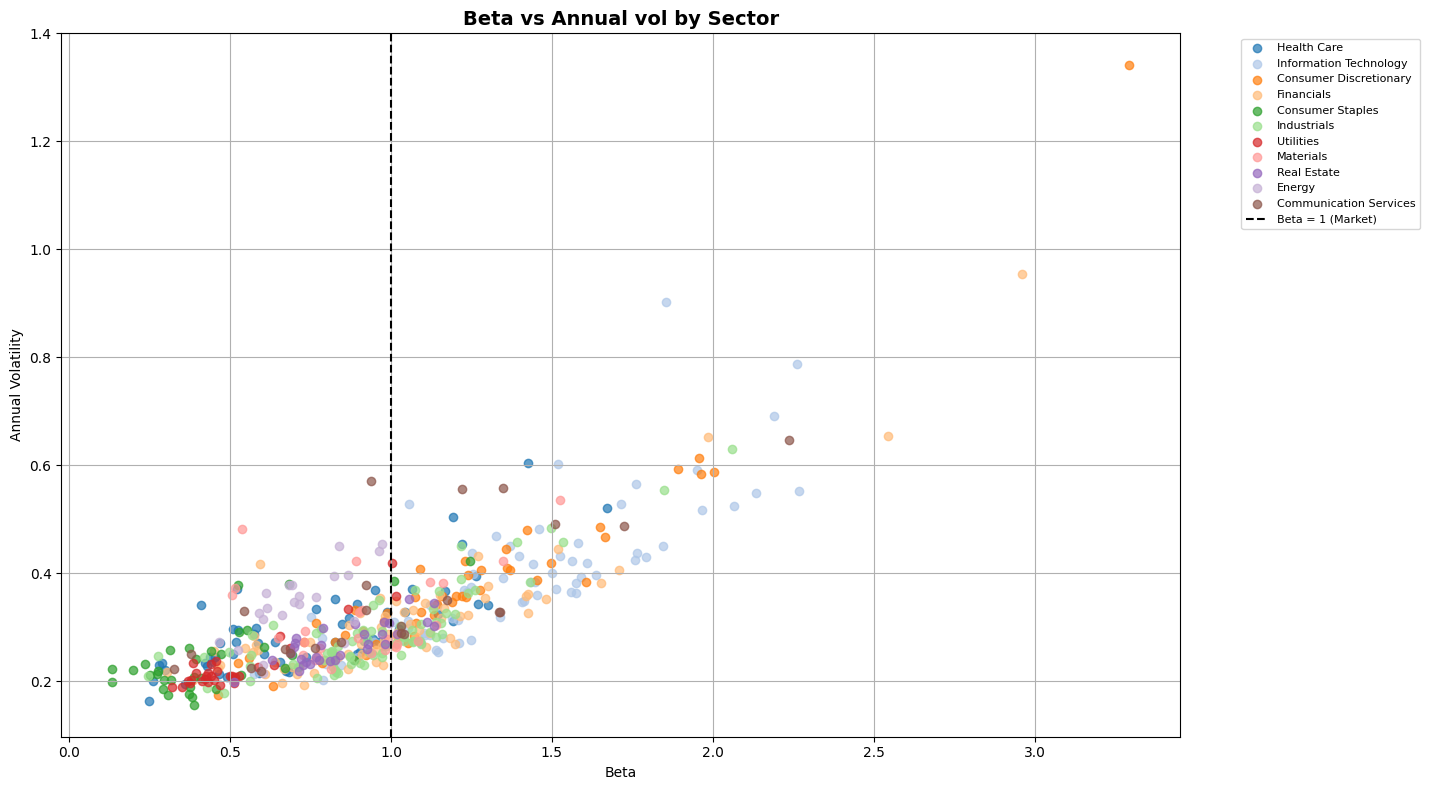

In [ ]:
# scatter plot - beta vs annual vol by sector

plt.figure(figsize=(12, 8))
sectors = metrics_df['Sector'].unique()
colors = plt.cm.tab20.colors

for i, sector in enumerate(sectors):
    mask = metrics_df['Sector'] == sector
    plt.scatter(metrics_df[mask]['Beta'],
                metrics_df[mask]['Annual Volatility'],
                label = sector, color = colors[i % len(colors)], alpha = 0.7)

plt.axvline(x = 1, color = 'black', linestyle = '--', label='Beta = 1 (Market)')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.title('Beta vs Annual vol by Sector', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True)
plt.show()

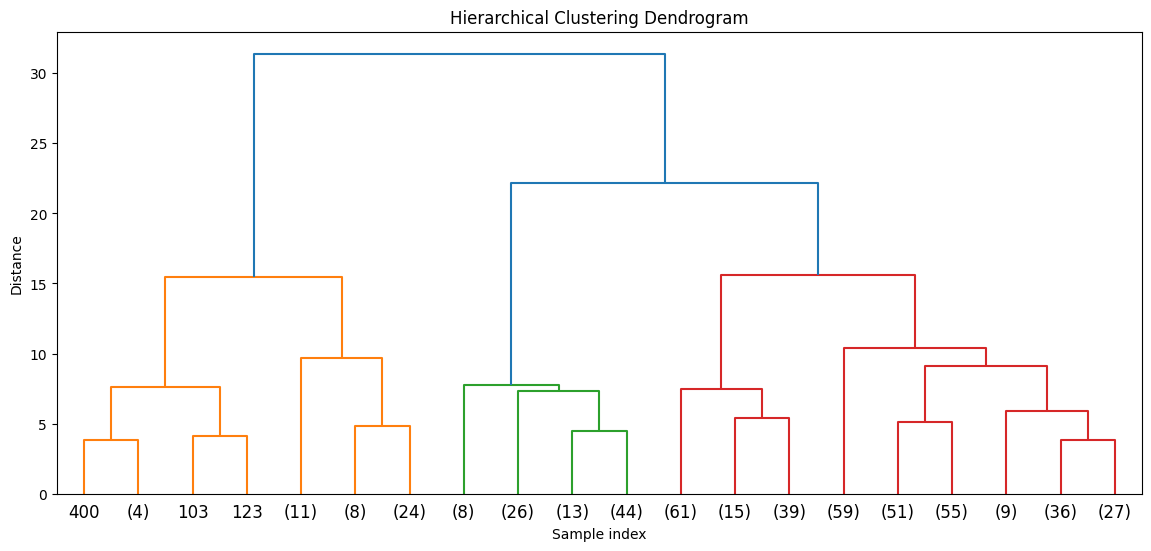

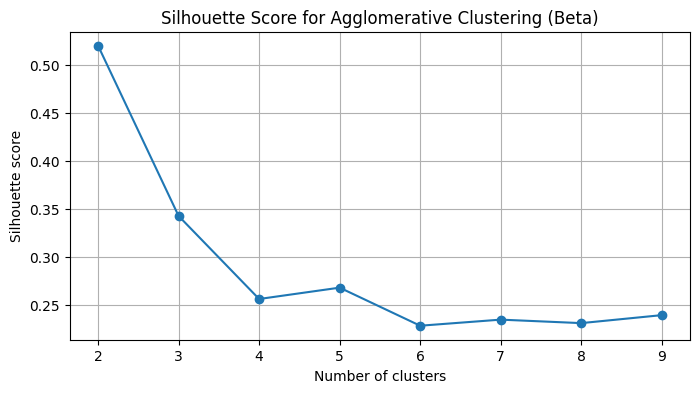

Best N clusters: 2
Best silhouette score: 0.5205


In [ ]:
# PART B
# stock segmentation with agglomerative clustering
# BETA

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

#assigning Beta column to X

X = metrics_df[['Daily_Return', 'Beta', 'Annual Volatility']]

# scaling the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# First technique - using a dendogram to find optimal N

plt.figure(figsize=(14, 6))
linked = linkage(X_scaled, 'ward')
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

# second technique - using the sillhouette score

range_n_clusters = [2, 3, 4 ,5 ,6 ,7, 8, 9]
scores = []

for n_clusters in range_n_clusters:
  agglom = AgglomerativeClustering(n_clusters=n_clusters)
  labels = agglom.fit_predict(X_scaled)
  scores.append(silhouette_score(X_scaled, labels))

#graphing

plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score for Agglomerative Clustering (Beta)')
plt.grid(True)
plt.show()

print(f"Best N clusters: {range_n_clusters[scores.index(max(scores))]}")
print(f"Best silhouette score: {max(scores):.4f}")

                Daily_Return      Beta  Annual Volatility
Agglom_Cluster                                           
0                   0.000422  0.756263           0.263718
1                  -0.000095  1.277735           0.395224
2                   0.001520  1.665859           0.524762


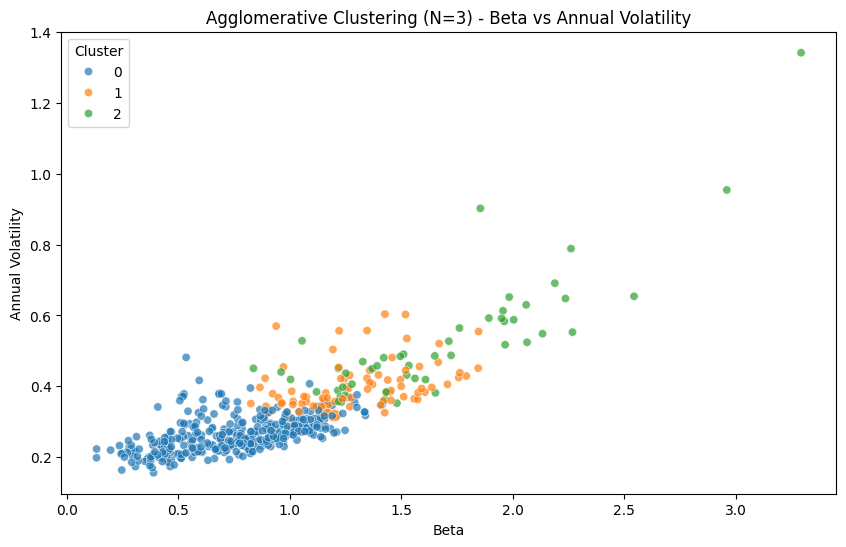

                Daily_Return      Beta  Annual Volatility
Agglom_Cluster                                           
0                   0.000422  0.756263           0.263718
1                  -0.000095  1.277735           0.395224
2                   0.001520  1.665859           0.524762


In [ ]:
# optimal no of clusters - model

optimal_n = 3
agglom = AgglomerativeClustering(n_clusters=optimal_n)

metrics_df['Agglom_Cluster'] = agglom.fit_predict(X_scaled)

# Fix cluster labels - 0=low risk, 1=medium risk, 2=high risk
cluster_means = metrics_df.groupby('Agglom_Cluster')['Beta'].mean().sort_values()
label_mapping = {old: new for new, old in enumerate(cluster_means.index)}
metrics_df['Agglom_Cluster'] = metrics_df['Agglom_Cluster'].map(label_mapping)

cluster_means = metrics_df.groupby('Agglom_Cluster')['Beta'].mean().sort_values()
print(metrics_df.groupby('Agglom_Cluster')[['Daily_Return', 'Beta', 'Annual Volatility']].mean())


# visualisation

plt.figure(figsize=(10,6))
sns.scatterplot(data=metrics_df, x='Beta', y='Annual Volatility',
                hue='Agglom_Cluster', palette='tab10', alpha=0.7)
plt.title(f'Agglomerative Clustering (N={optimal_n}) - Beta vs Annual Volatility')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.legend(title='Cluster')
plt.show()

print(metrics_df.groupby('Agglom_Cluster')[['Daily_Return', 'Beta', 'Annual Volatility']].mean())

Skewness of each metric:
Daily_Return         0.975038
Beta                 1.092429
Annual Volatility    2.875455
dtype: float64


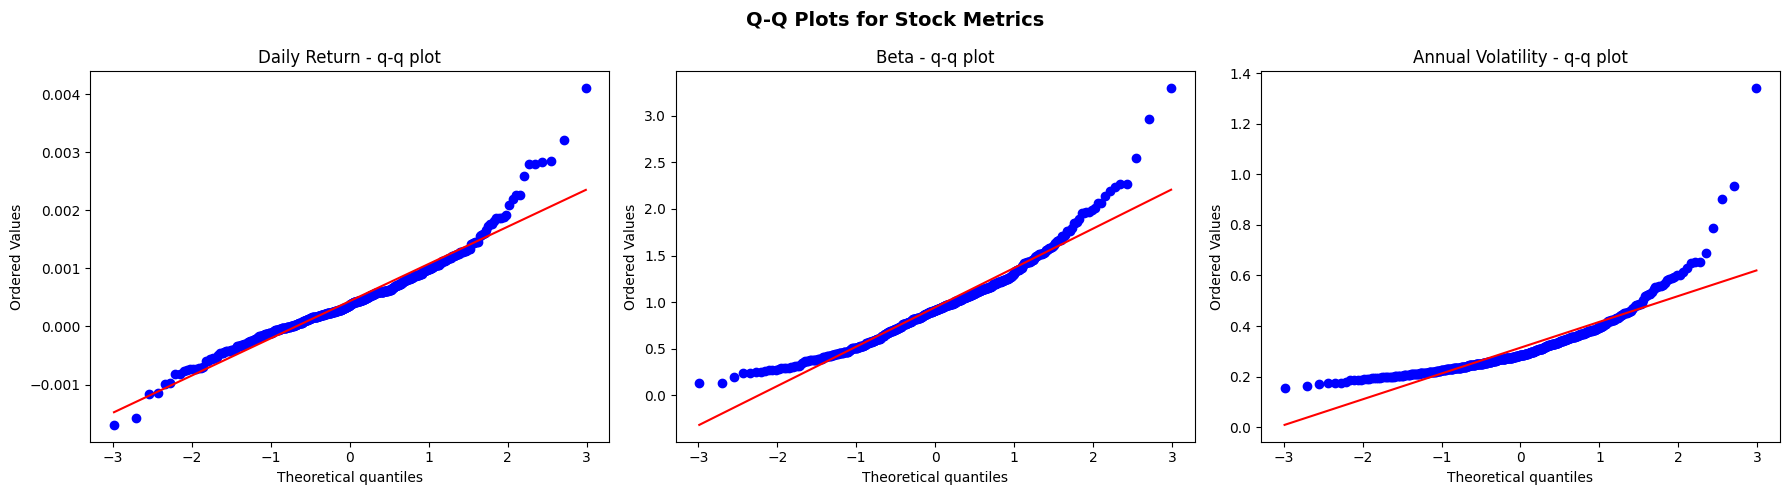

In [ ]:
# K-means clustering

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

# checking the skewness of the metrics

print("Skewness of each metric:")
print(metrics_df[['Daily_Return', 'Beta', 'Annual Volatility']].skew())

# visualisation

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

stats.probplot(metrics_df['Daily_Return'], plot=axes[0])
axes[0].set_title('Daily Return - q-q plot')

stats.probplot(metrics_df['Beta'], plot=axes[1])
axes[1].set_title('Beta - q-q plot')

stats.probplot(metrics_df['Annual Volatility'], plot=axes[2])
axes[2].set_title('Annual Volatility - q-q plot')

plt.suptitle('Q-Q Plots for Stock Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

red line is the normal distrib

all 3 metrics deviate from it (they're skewed)

we need to fix all three

we do it with log transformation

In [ ]:
# handling the skewness

metrics_df['Beta_log'] = np.log(metrics_df['Beta'])
metrics_df['Annual_Volatility_log'] = np.log(metrics_df['Annual Volatility'])

# Daily Return left as it is
# log transformation overcorrects due to negative values

print("Skewness before transformation:")
print(f"Daily Return: {metrics_df['Daily_Return'].skew():.3f}")
print(f"Beta: {metrics_df['Beta'].skew():.3f}")
print(f"Annual Volatility: {metrics_df['Annual Volatility'].skew():.3f}")

print("\nSkewness after transformation:")
print(f"Daily Return: {metrics_df['Daily_Return'].skew():.3f} (unchanged)")
print(f"Beta: {metrics_df['Beta_log'].skew():.3f} (log transformed)")
print(f"Annual Volatility: {metrics_df['Annual_Volatility_log'].skew():.3f} (log transformed)")

Skewness before transformation:
Daily Return: 0.975
Beta: 1.092
Annual Volatility: 2.875

Skewness after transformation:
Daily Return: 0.975 (unchanged)
Beta: -0.554 (log transformed)
Annual Volatility: 0.914 (log transformed)


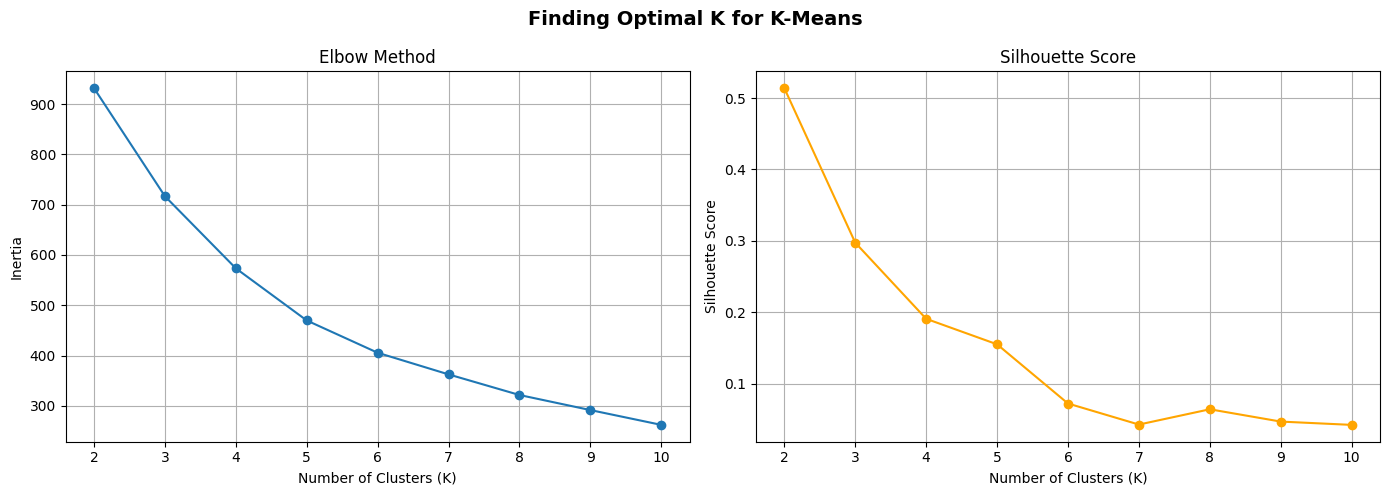

Best K: 2
Best silhouette score: 0.5140


In [ ]:
# creating a pipeline for the k-means

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# using the transf metrics

X_kmeans = metrics_df[['Daily_Return', 'Beta', 'Annual Volatility']]

# elbow and sillhouette to find optimal k

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=k, random_state=42, n_init=10))
    pipeline.fit(X_kmeans)
    inertia.append(pipeline.named_steps['kmeans'].inertia_)
    silhouette_scores.append(silhouette_score(X_kmeans, pipeline.named_steps['kmeans'].labels_))

# visualisation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(K_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.suptitle('Finding Optimal K for K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best K: {list(K_range)[silhouette_scores.index(max(silhouette_scores))]}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")

K-Means Cluster Profiles:
                Daily_Return      Beta  Annual Volatility
KMeans_Cluster                                           
0                   0.000473  0.692749           0.253053
1                   0.000048  1.170006           0.359858
2                   0.001507  1.720181           0.534489


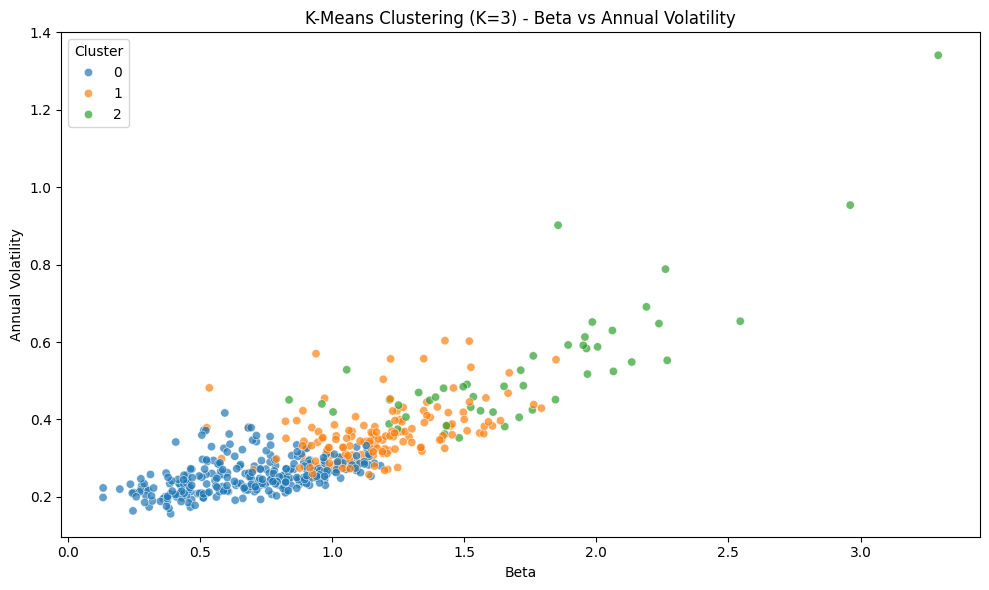

In [ ]:
# optimal no of kmeans - model
optimal_k = 3
pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_k, random_state=42, n_init=10))
pipeline.fit(X_kmeans)
metrics_df['KMeans_Cluster'] = pipeline.named_steps['kmeans'].labels_

# Fix cluster labels - 0=low risk, 1=medium risk, 2=high risk
cluster_means = metrics_df.groupby('KMeans_Cluster')['Beta'].mean().sort_values()
label_mapping = {old: new for new, old in enumerate(cluster_means.index)}
metrics_df['KMeans_Cluster'] = metrics_df['KMeans_Cluster'].map(label_mapping)

# profiles
print("K-Means Cluster Profiles:")
print(metrics_df.groupby('KMeans_Cluster')[['Daily_Return', 'Beta', 'Annual Volatility']].mean())

# visualisation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=metrics_df, x='Beta', y='Annual Volatility',
                hue='KMeans_Cluster', palette='tab10', alpha=0.7)
plt.title(f'K-Means Clustering (K={optimal_k}) - Beta vs Annual Volatility')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# Compare cluster assignments
print("Agglomerative clusters:")
print(metrics_df['Agglom_Cluster'].value_counts())

print("\nK-Means clusters:")
print(metrics_df['KMeans_Cluster'].value_counts())

Agglomerative clusters:
Agglom_Cluster
0    352
1     91
2     50
Name: count, dtype: int64

K-Means clusters:
KMeans_Cluster
0    288
1    157
2     48
Name: count, dtype: int64
